In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
data = fetch_california_housing()

X = data.data
y = data.target.reshape(-1, 1)

print(X.shape)  # (20640, 8)
print(y.shape)  # (20640, 1)

(20640, 8)
(20640, 1)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
np.random.seed(42)

n_inputs = X_train.shape[1]
n_hidden = 16
n_outputs = 1

W1 = np.random.randn(n_inputs, n_hidden) * 0.01
b1 = np.zeros((1, n_hidden))

W2 = np.random.randn(n_hidden, n_outputs) * 0.01
b2 = np.zeros((1, n_outputs))

In [16]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

In [17]:
learning_rate = 0.01
epochs = 1000
m = X_train.shape[0]

loss_history = []

In [18]:
for epoch in range(epochs):

    # Forward Pass
    Z1 = np.dot(X_train, W1) + b1
    A1 = relu(Z1)
    
    Z2 = np.dot(A1, W2) + b2
    y_pred = Z2   # linear output for regression

    # Compute Loss (MSE)
    loss = np.mean((y_train - y_pred) ** 2)
    loss_history.append(loss)

    # Backpropagation
    dZ2 = -2 * (y_train - y_pred) / m
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update Parameters
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

print("Training complete.")

Training complete.


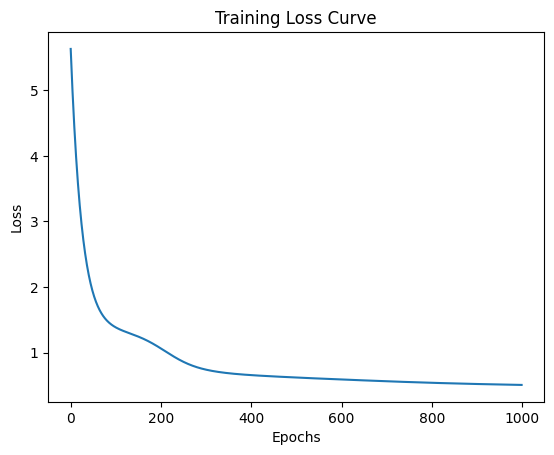

In [19]:
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [20]:
Z1_test = np.dot(X_test, W1) + b1
A1_test = relu(Z1_test)
Z2_test = np.dot(A1_test, W2) + b2
y_test_pred = Z2_test

mse_test = np.mean((y_test - y_test_pred) ** 2)
print("Test MSE:", mse_test)

Test MSE: 0.5269096483055487
